<a href="https://colab.research.google.com/github/diogenesjusto/FIAP/blob/master/Gradu%C3%A7%C3%A3o/2025/20251014_pyCaret_Importancia_Variaveis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
# A partir de Ago2025 o colab está com o Python 3.12. Versão de out/25 do pytcaret roda com Python até 3.11
# Comando abaixo permite rodar no colab 3.12 ref: https://stackoverflow.com/questions/74295700/cannot-import-pycaret-in-google-colab
!pip install git+https://github.com/pycaret/pycaret.git@master --upgrade

  Cloning https://github.com/pycaret/pycaret.git (to revision master) to /tmp/pip-req-build-mljmvaf9
  Running command git clone --filter=blob:none --quiet https://github.com/pycaret/pycaret.git /tmp/pip-req-build-mljmvaf9
  Resolved https://github.com/pycaret/pycaret.git to commit 58ec3c282d58e94727f9d5b77b49f241e9103ab3
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 238.4/238.4 kB 7.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 301.8/301.8 kB 21.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.0/24.0 MB 64.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 460.2/460.2 kB 26.1 MB/s eta 0:00:00
  Created wheel for pycaret: filename=pycaret-3.4.0-py3-none-any.whl size=491177 sha256=aea42aeceb6ac60b4947c2cb560a815f15c5bedcc4646ce975552ac7b991fd5d
  Stored in directory: /tm

In [3]:
from pycaret.classification import *

In [4]:
# Carga de dados
import pandas as pd
df = pd.read_csv("https://raw.githubusercontent.com/diogenesjusto/FIAP/master/dados/train.csv")

In [5]:
df

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S
...,...,...,...,...,...,...,...,...,...,...,...,...
886,887,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.0000,NaN,S
887,888,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.0000,B42,S
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,NaN,1,2,W./C. 6607,23.4500,NaN,S
889,890,1,1,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.0000,C148,C


In [6]:
# Vamos iniciar a utilização do Pycaret através do Setup
pycDF = setup(data=df, target='Survived', )

AttributeError: module 'pycaret' has no attribute 'utils'

In [7]:
df

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S
...,...,...,...,...,...,...,...,...,...,...,...,...
886,887,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.0000,NaN,S
887,888,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.0000,B42,S
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,NaN,1,2,W./C. 6607,23.4500,NaN,S
889,890,1,1,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.0000,C148,C


In [11]:
import numpy as np

dummy_sex = pd.get_dummies(df['Sex'])

df['Sex_female'] = dummy_sex['female']

dummy_pclass = pd.get_dummies(df['Pclass'], prefix='Class')
df['Class_1'] = dummy_pclass['Class_1']
df['Class_2'] = dummy_pclass['Class_2']

df['Women_or_Children'] = np.where(
  df['Age']<14,
  1,
  np.where(
      df['Sex_female']==1,
      1,
      0
  )
)

In [33]:
from sklearn.inspection import permutation_importance

from sklearn.model_selection import train_test_split
from matplotlib import pyplot as plt

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

X_treino, X_teste, Y_treino, Y_teste = train_test_split(
  df[['Class_1', 'Class_2', 'Sex_female', 'Women_or_Children']],
  df['Survived'],
  test_size=0.25, random_state=2
  )


In [29]:
mod = RandomForestClassifier().fit(X_treino, Y_treino)
#

# Avaliação de importância de variáveis => Peso do coeficiente
#mod.coef_

Text(0.5, 0, 'Permutation Importance')

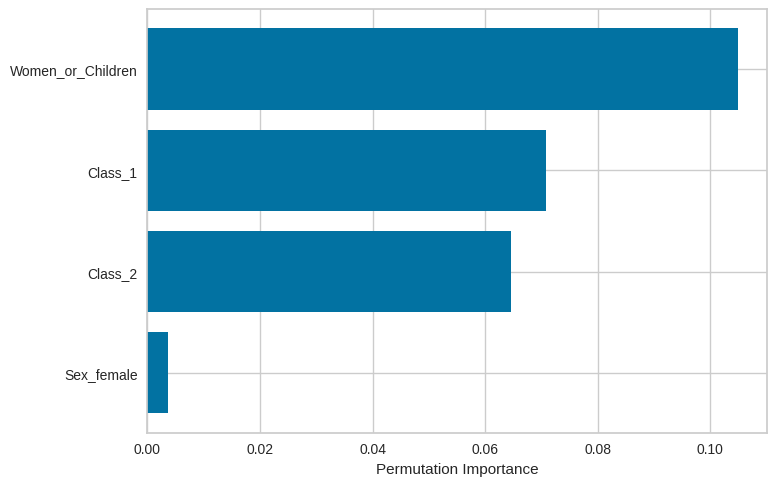

In [35]:
# O método de permutação permite que generalizemos, ou seja, utilizemos avaliação de importância para qualquer algoritmo
perm_importance = permutation_importance(mod, X_teste, Y_teste)

ordem_idx = perm_importance.importances_mean.argsort()
plt.barh(X_teste.columns[ordem_idx], perm_importance.importances_mean[ordem_idx])
plt.xlabel("Permutation Importance")